Nom : Khadijetou Mohamed abe

Filière : GLCC

# 1. CODE SCRATCH

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Étape 1 : Centrage des données
def centrer_donnees(X):
    # """
    # L'ACP nécessite que l'origine du repère soit au centre de gravité du nuage de points.
    # On calcule la moyenne de chaque colonne et on la soustrait aux données.
    # """
    # np.mean(X, axis=0) calcule la moyenne pour chaque colonne (axe 0)
    moyenne = np.mean(X, axis=0)
    # On soustrait la moyenne à la matrice originale
    X_centre = X - moyenne
    return X_centre, moyenne

# Étape 2 : Formulation matricielle de la variance/covariance
def matrice_covariance(X_centre):
    # """
    # La matrice de covariance Σ = (1 / (n - 1)) * X_centre.T . X_centre
    # """
    # nombre de lignes
    n = X_centre.shape[0]
    # On calcule le produit matriciel de la transposée de X_centre par X_centre
    cov_mat = (1 / (n - 1)) * np.dot(X_centre.T, X_centre)
    return cov_mat


# Étape 3 : Déterminer les valeurs propres et vecteurs propres
def composantes_principales(cov_mat):
    # """
    # 1- la norme du vecteur u vaut 1 (u.T * u = 1) 
    # 2- l'équation des valeurs propres : Σ * u = λ * u.
    # """
    # np.linalg.eig calcule les valeurs propres et les vecteurs propres
    valeurs_propres, vecteurs_propres = np.linalg.eig(cov_mat)
    
    # On trie les valeurs propres par ordre décroissant (du plus grand au plus petit)
    indices_tries = np.argsort(valeurs_propres)[::-1]
    
    # On réorganise les valeurs et les vecteurs selon ces indices
    valeurs_propres_triees = valeurs_propres[indices_tries]
    vecteurs_propres_tries = vecteurs_propres[:, indices_tries]
    
    return valeurs_propres_triees, vecteurs_propres_tries


 # Étape 4 : Variance Totale et Variance Expliquée
def calculer_variance_expliquee(valeurs_propres):
    # """
    # La variance totale est la somme de toutes les valeurs propres.
    # La variance expliquée est le pourcentage d'information conservée par chaque axe. (eig_i / somme_totale(eig)) * 100
    # """
    variance_totale = np.sum(valeurs_propres)
    # On calcule le pourcentage pour chaque valeur propre
    variance_expliquee = [(val / variance_totale) * 100 for val in valeurs_propres]
    return variance_expliquee

# Étape 5 : Généralisation à r dimensions et Projection
def projeter_donnees(X_centre, vecteurs_propres, r_dimensions):
    # """
    # Pour r dimensions multiples (par exemple r=2), on sélectionne les r premiers vecteurs propres.
    # Ensuite, on projette les données centrées sur ces nouveaux axes.
    # Formule : X_projete = X_centre . W (où W contient les r vecteurs propres)
    # """
    # On extrait les 'r' premières colonnes (les 'r' meilleurs vecteurs propres)
    W = vecteurs_propres[:, :r_dimensions]
    # On fait le produit matriciel pour projeter
    X_projete = np.dot(X_centre, W)
    return X_projete, W

## a. DATASET

In [28]:
# Imaginons les notes de 10 étudiants en Mathématiques et en Physique
# On s'attend à ce que les notes soient corrélées (ceux bons en math sont souvent bons en physique)
X_data_acp = np.array([
        [10, 5], [15, 16], [18, 10], [5, 13], [12, 12],
    [9, 15], [8, 9], [2, 5], [17, 20], [16, 10]
])

## b. Exécution du code scratch

In [29]:
# 1. Centrage
X_centre_scratch, moyenne_scratch = centrer_donnees(X_data_acp)

# 2. Matrice de covariance
cov_mat_scratch = matrice_covariance(X_centre_scratch)

# 3. Valeurs et vecteurs propres
val_propres_scratch, vect_propres_scratch = composantes_principales(cov_mat_scratch)

# 4. Variance expliquée
var_exp_scratch = calculer_variance_expliquee(val_propres_scratch)

# 5. Projection sur 2 dimensions (r = 2)
# (Même si c'est déjà en 2D, on le fait pour obtenir nos axes C1 et C2)
X_proj_scratch, W_scratch = projeter_donnees(X_centre_scratch, vect_propres_scratch, r_dimensions=2)

## c. Code sklearn

In [30]:
# import de la classe PCA de scikit-learn
from sklearn.decomposition import PCA

# On instancie l'objet PCA en demandant 2 composantes (r = 2)
modele_sklearn_pca = PCA(n_components=2)

# On entraîne le modèle et on projette les données en une seule étape
X_proj_sklearn = modele_sklearn_pca.fit_transform(X_data_acp)

# On récupère les résultats de sklearn
moyenne_sklearn = modele_sklearn_pca.mean_

# Dans sklearn, les vecteurs propres sont en LIGNES (components_), 
# on les transpose (.T) pour les avoir en colonnes comme dans notre scratch
vect_propres_sklearn = modele_sklearn_pca.components_.T
var_exp_sklearn = modele_sklearn_pca.explained_variance_ratio_ * 100


## d. Comparaison et graphiques (scratch/sklearn)

--- RÉSULTATS SCRATCH ---
Centre de gravité (Moyenne) : [11.2 11.5]
Vecteurs propres (Axes C1 et C2 en colonnes) :
 [[ 0.78967625 -0.61352378]
 [ 0.61352378  0.78967625]]
Variance expliquée par C1 : 74.2248475713649 %
Variance expliquée par C2 : 25.775152428635096 %

--- RÉSULTATS SKLEARN ---
Centre de gravité (Moyenne) : {moyenne_sklearn}
Vecteurs propres (Axes C1 et C2 en colonnes) :
 [[ 0.78967625 -0.61352378]
 [ 0.61352378  0.78967625]]
Variance expliquée par C1 : 74.22484757136492 %
Variance expliquée par C2 : 25.775152428635085 %


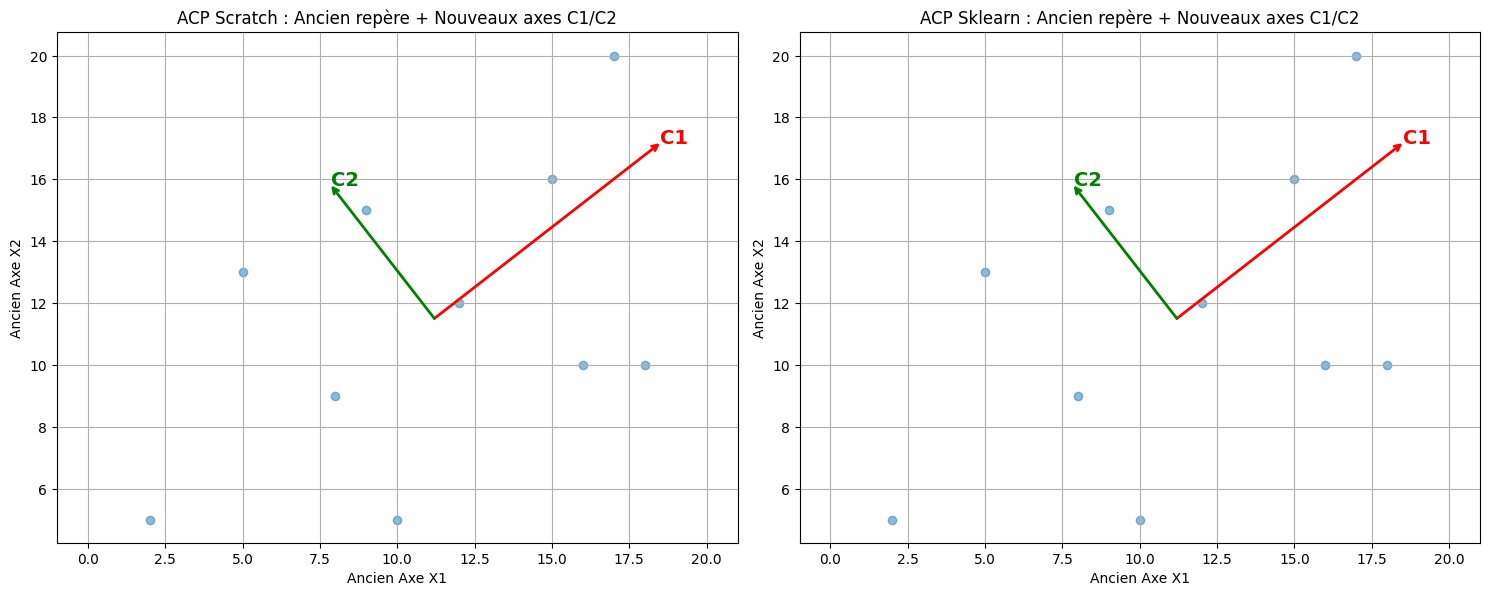

In [31]:

print("--- RÉSULTATS SCRATCH ---")
print("Centre de gravité (Moyenne) :",moyenne_scratch)
print("Vecteurs propres (Axes C1 et C2 en colonnes) :\n",vect_propres_scratch)
print("Variance expliquée par C1 :", var_exp_scratch[0],"%")
print("Variance expliquée par C2 :", var_exp_scratch[1],"%\n")

print("--- RÉSULTATS SKLEARN ---")
print("Centre de gravité (Moyenne) : {moyenne_sklearn}")
print("Vecteurs propres (Axes C1 et C2 en colonnes) :\n",vect_propres_sklearn)
print("Variance expliquée par C1 :", var_exp_sklearn[0],"%")
print("Variance expliquée par C2 :", var_exp_sklearn[1],"%")


def dessiner_vecteur(v0, v1, ax, couleur, label):
    """Dessine une flèche représentant un vecteur propre."""
    ax.annotate('', xy=v0 + v1, xytext=v0,
                arrowprops=dict(arrowstyle='->', linewidth=2, color=couleur, shrinkA=0, shrinkB=0),
                label=label)

def tracer_acp(ax, X_data, moyenne, val_propres, vect_propres, titre):
    """Fonction générique pour tracer les données, les axes C1/C2 et formater le graphe."""
    # 1. Tracer les points d'origine
    ax.scatter(X_data[:, 0], X_data[:, 1], alpha=0.5, label="Points d'origine")

    # Initialiser les limites de base (On garantit au moins 0 à 20 pour X)
    x_min, x_max = 0, 20
    y_min, y_max = X_data[:, 1].min(), X_data[:, 1].max()

    # 2. Tracer les vecteurs propres
    for i, (val, vect) in enumerate(zip(val_propres, vect_propres)):
        # On réduit le multiplicateur à 1.5 pour éviter des flèches géantes
        longueur_vecteur = vect * np.sqrt(val) * 1.5 
        nom_axe = f"C{i+1}"
        couleur = 'red' if i == 0 else 'green'
        
        dessiner_vecteur(moyenne, longueur_vecteur, ax, couleur, nom_axe)
        
        # Position exacte de la pointe de la flèche
        x_pointe = moyenne[0] + longueur_vecteur[0]
        y_pointe = moyenne[1] + longueur_vecteur[1]
        
        # Ajouter le texte (C1/C2)
        ax.text(x_pointe, y_pointe, nom_axe, color=couleur, fontsize=14, weight='bold')
                
        # Mettre à jour les limites pour s'assurer que la pointe rentre dans le cadre
        x_min = min(x_min, x_pointe)
        x_max = max(x_max, x_pointe)
        y_min = min(y_min, y_pointe)
        y_max = max(y_max, y_pointe)

    # 3. Mise en forme du graphique
    ax.set_title(titre)
    ax.set_xlabel('Ancien Axe X1')
    ax.set_ylabel('Ancien Axe X2')
    ax.grid(True)
    
    # Appliquer les limites dynamiques avec une petite marge esthétique de 5%
    marge_x = (x_max - x_min) * 0.05
    marge_y = (y_max - y_min) * 0.05
    
    ax.set_xlim(x_min - marge_x, x_max + marge_x)
    ax.set_ylim(y_min - marge_y, y_max + marge_y)
    
    # Garder l'échelle 1:1 sans déformer les données
    ax.set_aspect('equal', adjustable='box')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 1 : Scratch (On passe vect_propres.T pour itérer sur les vecteurs)
tracer_acp(ax=ax1, X_data=X_data_acp, moyenne=moyenne_scratch, val_propres=val_propres_scratch, vect_propres=vect_propres_scratch.T, titre='ACP Scratch : Ancien repère + Nouveaux axes C1/C2')

# Graphique 2 : Sklearn
tracer_acp(ax=ax2, X_data=X_data_acp, moyenne=moyenne_sklearn, val_propres=modele_sklearn_pca.explained_variance_, vect_propres=vect_propres_sklearn.T, titre='ACP Sklearn : Ancien repère + Nouveaux axes C1/C2')

plt.tight_layout()
plt.show()